# 🚢 Titanic Survival — Exploratory Data Analysis

## 🎯 Project Objective
This notebook explores the Titanic passenger dataset to understand which factors — such as gender, passenger class, age, and fare — were associated with a passenger's chances of survival. The workflow covers data cleaning, dtype optimization, and univariate/bivariate visual analysis using `pandas`, `matplotlib`, and `seaborn`.

## 📋 Dataset Overview
The dataset contains passenger-level records from the RMS Titanic (1912), commonly used as a beginner-friendly benchmark dataset for classification and EDA practice.

**Columns:**

| Column        | Description                                              |
|---------------|------------------------------------------------------------|
| `PassengerId` | Unique ID for each passenger                              |
| `Survived`    | Survival status (0 = No, 1 = Yes) — **target variable**    |
| `Pclass`      | Ticket / passenger class (1 = 1st, 2 = 2nd, 3 = 3rd)        |
| `Name`        | Passenger's full name                                     |
| `Sex`         | Gender of the passenger                                   |
| `Age`         | Age in years                                               |
| `SibSp`       | Number of siblings/spouses aboard                          |
| `Parch`       | Number of parents/children aboard                          |
| `Ticket`      | Ticket number                                              |
| `Fare`        | Passenger fare                                             |
| `Cabin`       | Cabin number (many missing values)                          |
| `Embarked`    | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |

**Analysis roadmap:**
1. Load the data and inspect its shape, dtypes, and missing values
2. Clean missing values (`Cabin`, `Age`, `Embarked`) and optimize dtypes
3. Visualize distributions, categorical breakdowns, and survival patterns
4. Summarize key takeaways


---
### 📦 Importing Libraries
---

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
### 📥 Loading and Understanding the Dataset
---

In [119]:
df = pd.read_csv("titanic.csv")

In [120]:
df.shape

(891, 12)

In [121]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [122]:
df.columns.values

<StringArray>
['PassengerId',    'Survived',      'Pclass',        'Name',         'Sex',
         'Age',       'SibSp',       'Parch',      'Ticket',        'Fare',
       'Cabin',    'Embarked']
Length: 12, dtype: str

In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [124]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

---
### 🧹Data Cleaning
---

In [125]:
# Handle Cabin column
df.drop(columns=['Cabin'], inplace=True)  # Dropped due to a high percentage of missing values

In [126]:
# handle Age
df['Age'] = df['Age'].fillna(df.groupby(['Pclass','Sex'])['Age'].transform('median'))

In [127]:
df['Embarked'].value_counts()  # S is the most frequently occurring value

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [128]:
# handle Embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [130]:
# Optimize data types for memory efficiency: convert categorical features to 'category' and Age to 'int'
df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Age'] = df['Age'].astype('int')
df['Embarked'] = df['Embarked'].astype('category')

In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          891 non-null    int64   
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(4), float64(1), int64(4), str(2)
memory usage: 52.4 KB


In [132]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.072952,0.523008,0.381594,32.204208
std,257.353842,13.326339,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,21.000000,0.000000,0.000000,7.910400
50%,446.000000,26.000000,0.000000,0.000000,14.454200
75%,668.500000,36.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


---
### 📊 Data Visualization
---

### 1. 📈 Distribution of Age and Fare 

Shows the distribution of passenger ages and ticket fares, highlighting common age groups and fare ranges.

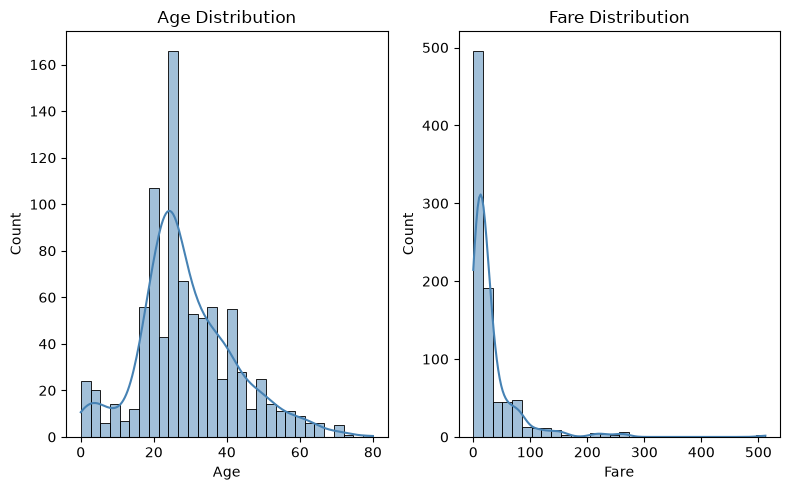

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
num_col = ['Age','Fare']

for i,col in enumerate(num_col):
    sns.histplot(x=col, data=df, bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout() #Adjust spacing
plt.savefig('images/graph1.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 2. 📈 Count Distribution of Categorical Columns (Sex, Pclass, Embarked, Survived)

Displays the frequency of each category for gender, passenger class, embarkation port, and survival status.

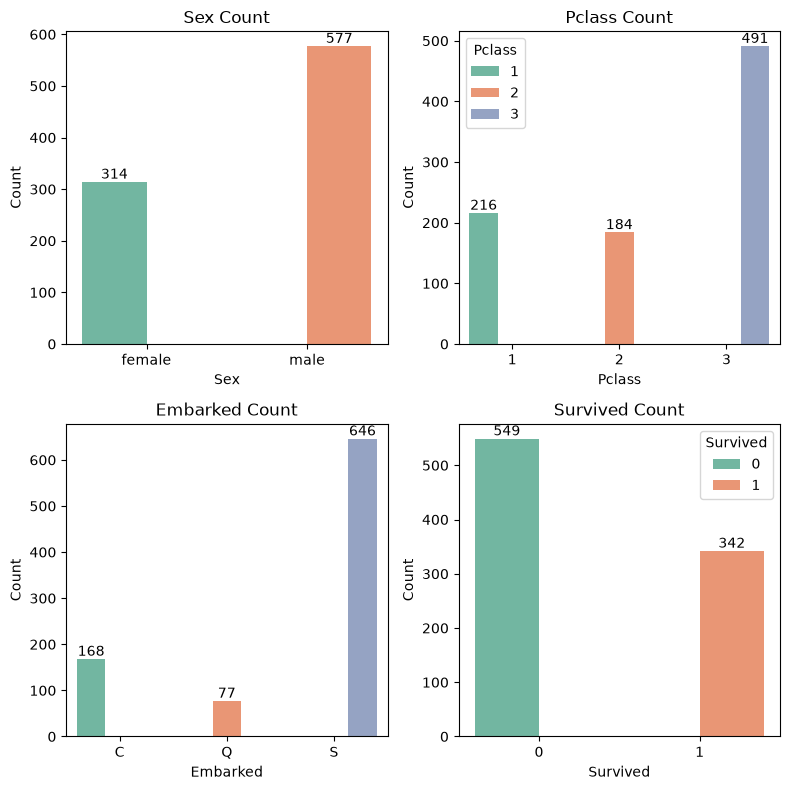

In [138]:
cat_col = ['Sex', 'Pclass', 'Embarked', 'Survived']
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten() #Converts the 2D array of axes into a 1D array so they can be accessed easily

for i, col in enumerate(cat_col):
    sns.countplot(x=col, data=df, ax=axes[i], hue=col, palette='Set2')
    axes[i].set_title(f'{col} Count')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    # Add value labels (only available in countplot)
    for container in axes[i].containers:
        axes[i].bar_label(container)

plt.tight_layout() #Adjust spacing
plt.savefig('images/graph2.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 3. 📈 Survival vs Categorical Features (Sex, Pclass, Embarked)

Compares survivor and non-survivor counts across gender, passenger class, and embarkation port.

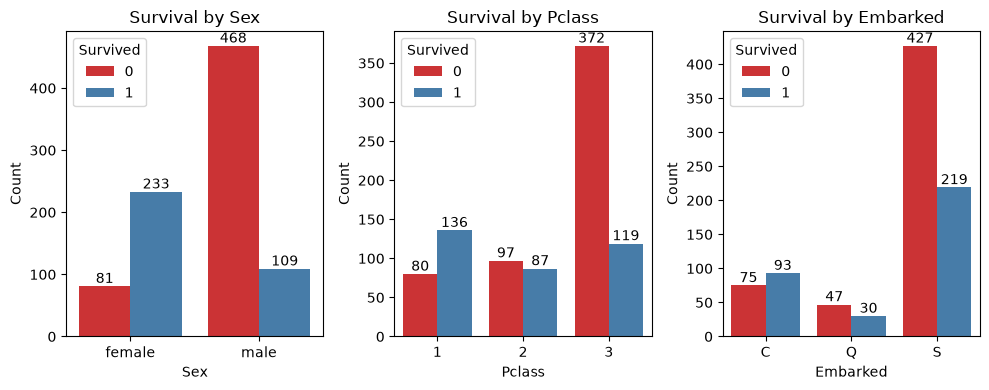

In [139]:
cat_cols = ['Sex', 'Pclass', 'Embarked']
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='Survived', ax=axes[i], palette='Set1')
    axes[i].set_title(f'Survival by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

    # Add value labels on bars
    for container in axes[i].containers:
        axes[i].bar_label(container)
        
plt.tight_layout() #Adjust spacing
plt.savefig('images/graph3.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 4. 📈 Age and Fare vs Survival

Compares age and fare distributions between survivors and non-survivors to identify potential survival patterns.

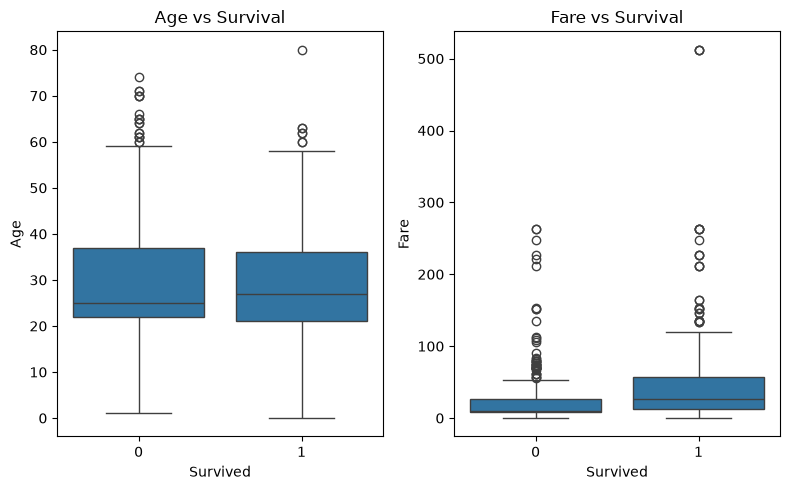

In [140]:
columns_name = ['Age', 'Fare']
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

for i, col in enumerate(columns_name):
    sns.boxplot(x='Survived', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Survival')
    
plt.tight_layout()
plt.savefig('images/graph4.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 5. 📈 Correlation using heatmap for numerical features

Visualizes relationships between numerical variables using correlation coefficients.

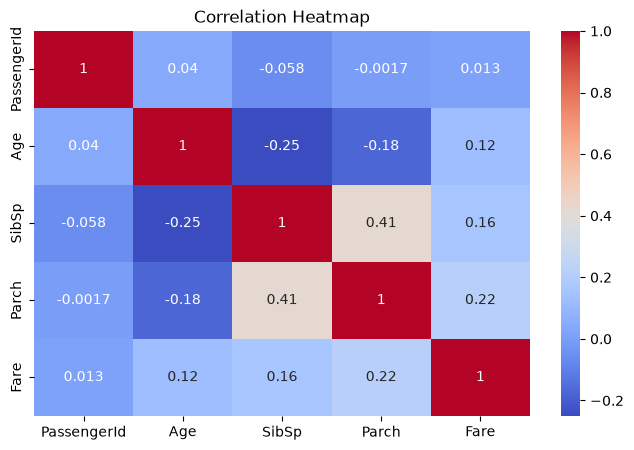

In [141]:
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

plt.savefig('images/grap5.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 6. 📈 Age Distribution by Survival

Shows the age distribution of survivors and non-survivors to identify age-related survival trends.

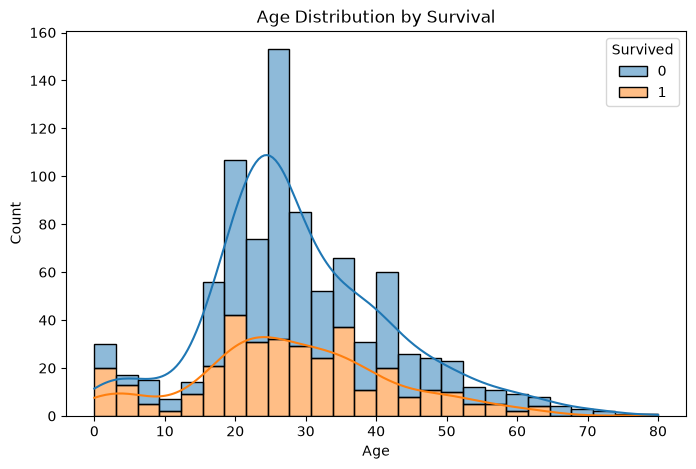

In [142]:
plt.figure(figsize=(8,5))

sns.histplot(data=df,x='Age', hue='Survived', kde=True, multiple='stack')
plt.title('Age Distribution by Survival')

plt.savefig('images/grap6.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 7. 📈 Pairplot for multiple numerical features

Explores relationships among numerical features and their association with survival status.

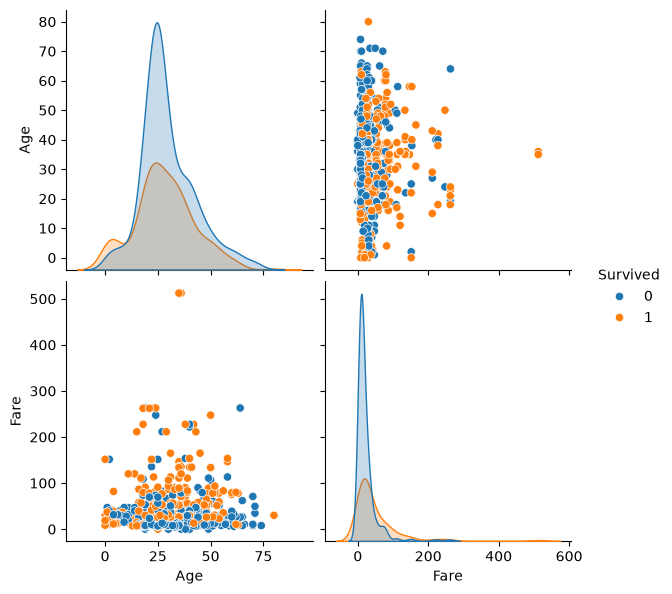

In [143]:
sns.pairplot(df[['Age', 'Fare', 'Pclass', 'Survived']], hue='Survived', height=3)

plt.savefig('images/graph7.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 8. 📈 Outlier Detection for Age and Fare

Identifies unusual age and fare values that differ significantly from the rest of the dataset.

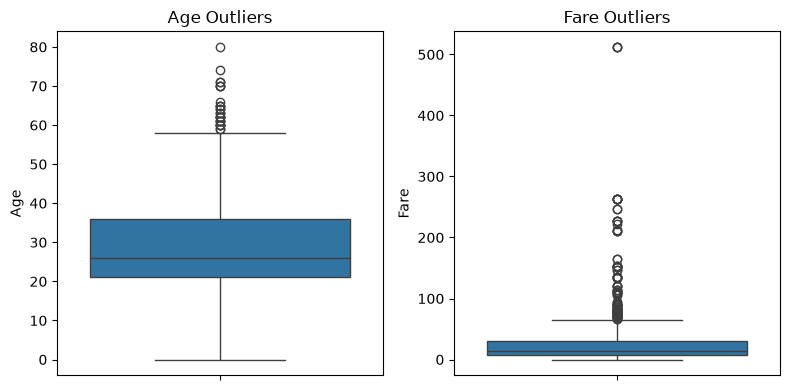

In [145]:
fig, axes = plt.subplots(1,2, figsize=(8,4))
num_col = ['Age','Fare']

for i,col in enumerate(num_col):
    sns.boxplot(y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} Outliers')

plt.tight_layout()
plt.savefig('images/graph8.png', dpi=300, bbox_inches='tight') #Saving graphs
plt.show()

### 9. 📈 Survival Rate by Gender and Passenger Class

Shows the percentage of survivors across genders and passenger classes, highlighting differences in survival rates.

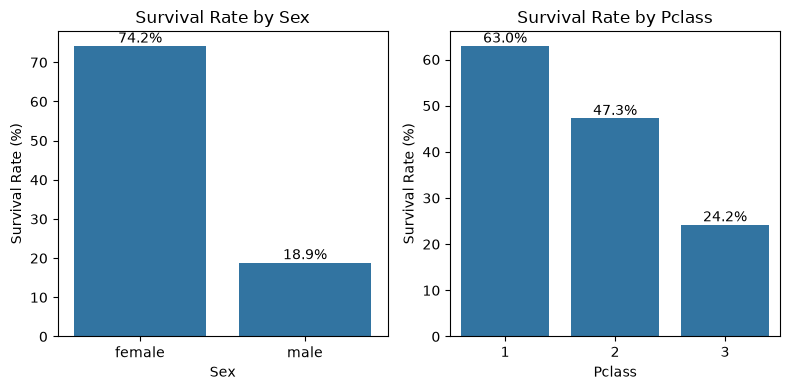

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
rate_cols = ['Sex','Pclass']

for i,col in enumerate(rate_cols):
    survival_rate = (df.groupby(col)['Survived'].apply(lambda x: (x == 1).mean() * 100))
    sns.barplot(x=survival_rate.index, y=survival_rate.values, ax=axes[i])
    axes[i].set_title(f'Survival Rate by {col}')
    axes[i].set_ylabel('Survival Rate (%)')
    axes[i].set_xlabel(col)
    #display values on bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.savefig('images/graph9.png', dpi=300, bbox_inches='tight')
plt.show()

---
### ✅ Key Takeaways
---
- **Gender**: Women had a substantially higher survival rate than men, consistent with the "women and children first" evacuation policy.
- **Passenger Class**: 1st class passengers survived at a much higher rate than 2nd and 3rd class, reflecting cabin location and access to lifeboats.
- **Fare**: Higher fares (correlated with class) were associated with better survival odds.
- **Age**: Younger passengers, especially children, had somewhat better survival odds than older adults.
- **Embarked**: Port of embarkation shows some association with survival, likely acting as a proxy for class/fare rather than a direct cause.
